In [61]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
import seaborn as sns

In [62]:
panel_data = pd.read_csv(r'a-fanning-doughnut-v3-a0460e5\Analysis-Final\myData\11_20250115_multiPanelData.csv')

In [63]:
panel_data.head()

,domain,dimension,type,group,grpCode,indicator,indCode,date,populationTotal,GNIperCap,value,boundary,ratio
0,ecological,climate change,national aggregate,Bottom-40,B40,co2_footprint,CC3,2017,3279187003,5022.645571,0.938904,0.95,-0.011680
1,ecological,climate change,national aggregate,Middle-40,M40,co2_footprint,CC3,2017,3183138611,15659.215592,4.256704,0.95,3.480741
2,ecological,climate change,national aggregate,Top-20,T20,co2_footprint,CC3,2017,985730708,51581.715835,11.650509,0.95,11.263694
3,ecological,nutrient pollution,national aggregate,Bottom-40,B40,P_footprint,NP3,2017,3279187003,5022.645571,1.536249,0.85,0.807352
4,ecological,nutrient pollution,national aggregate,Middle-40,M40,P_footprint,NP3,2017,3183138611,15659.215592,3.081177,0.85,2.624914


In [64]:
social_short = panel_data[panel_data['domain'] == 'social']

In [65]:
social_short.reset_index(drop='True', inplace=True)

In [66]:
soc_chart = social_short.groupby(['indicator', 'group'])['value'].sum().reset_index()

In [67]:
indicator_map = {
    'UHCindex': 'Lack of health services',
    'adultLiteracy': 'Illiteracy rate',
    'controlCorruption': 'Perceptions of corruption',
    'drinkingH2O': 'Unsafe drinking water',
    'energyAccess': 'Lack of electricity',
    'energyIndoor': 'Lack of clean fuels indoors',
    'foodInsecurity': 'Food insecurity',
    'genderGapIndex': 'Gender inequality',
    'govRegimes': 'Autocratic regimes',
    'homicideOver5': 'Homicide rate',
    'internet': 'Lack of internet',
    'palma': 'Income inequality',
    'publicTrans': 'Lack of public transport',
    'sanitation': 'Unsafe sanitation',
    'secondarySchool': 'Incomplete secondary school',
    'socialSupport': 'Lack of social support',
    'societalPoverty': 'Societal poverty',
    'under5death': 'Under-5 mortality',
    'undernourishment': 'Undernourished',
    'urbanSlums': 'Slums or informal housing',
    'youthNEET': 'Youth NEET'
}

In [68]:
soc_chart['indicator'] = soc_chart['indicator'].map(indicator_map)

In [69]:
soc_chart.sort_values(['indicator', 'group'], inplace=True)

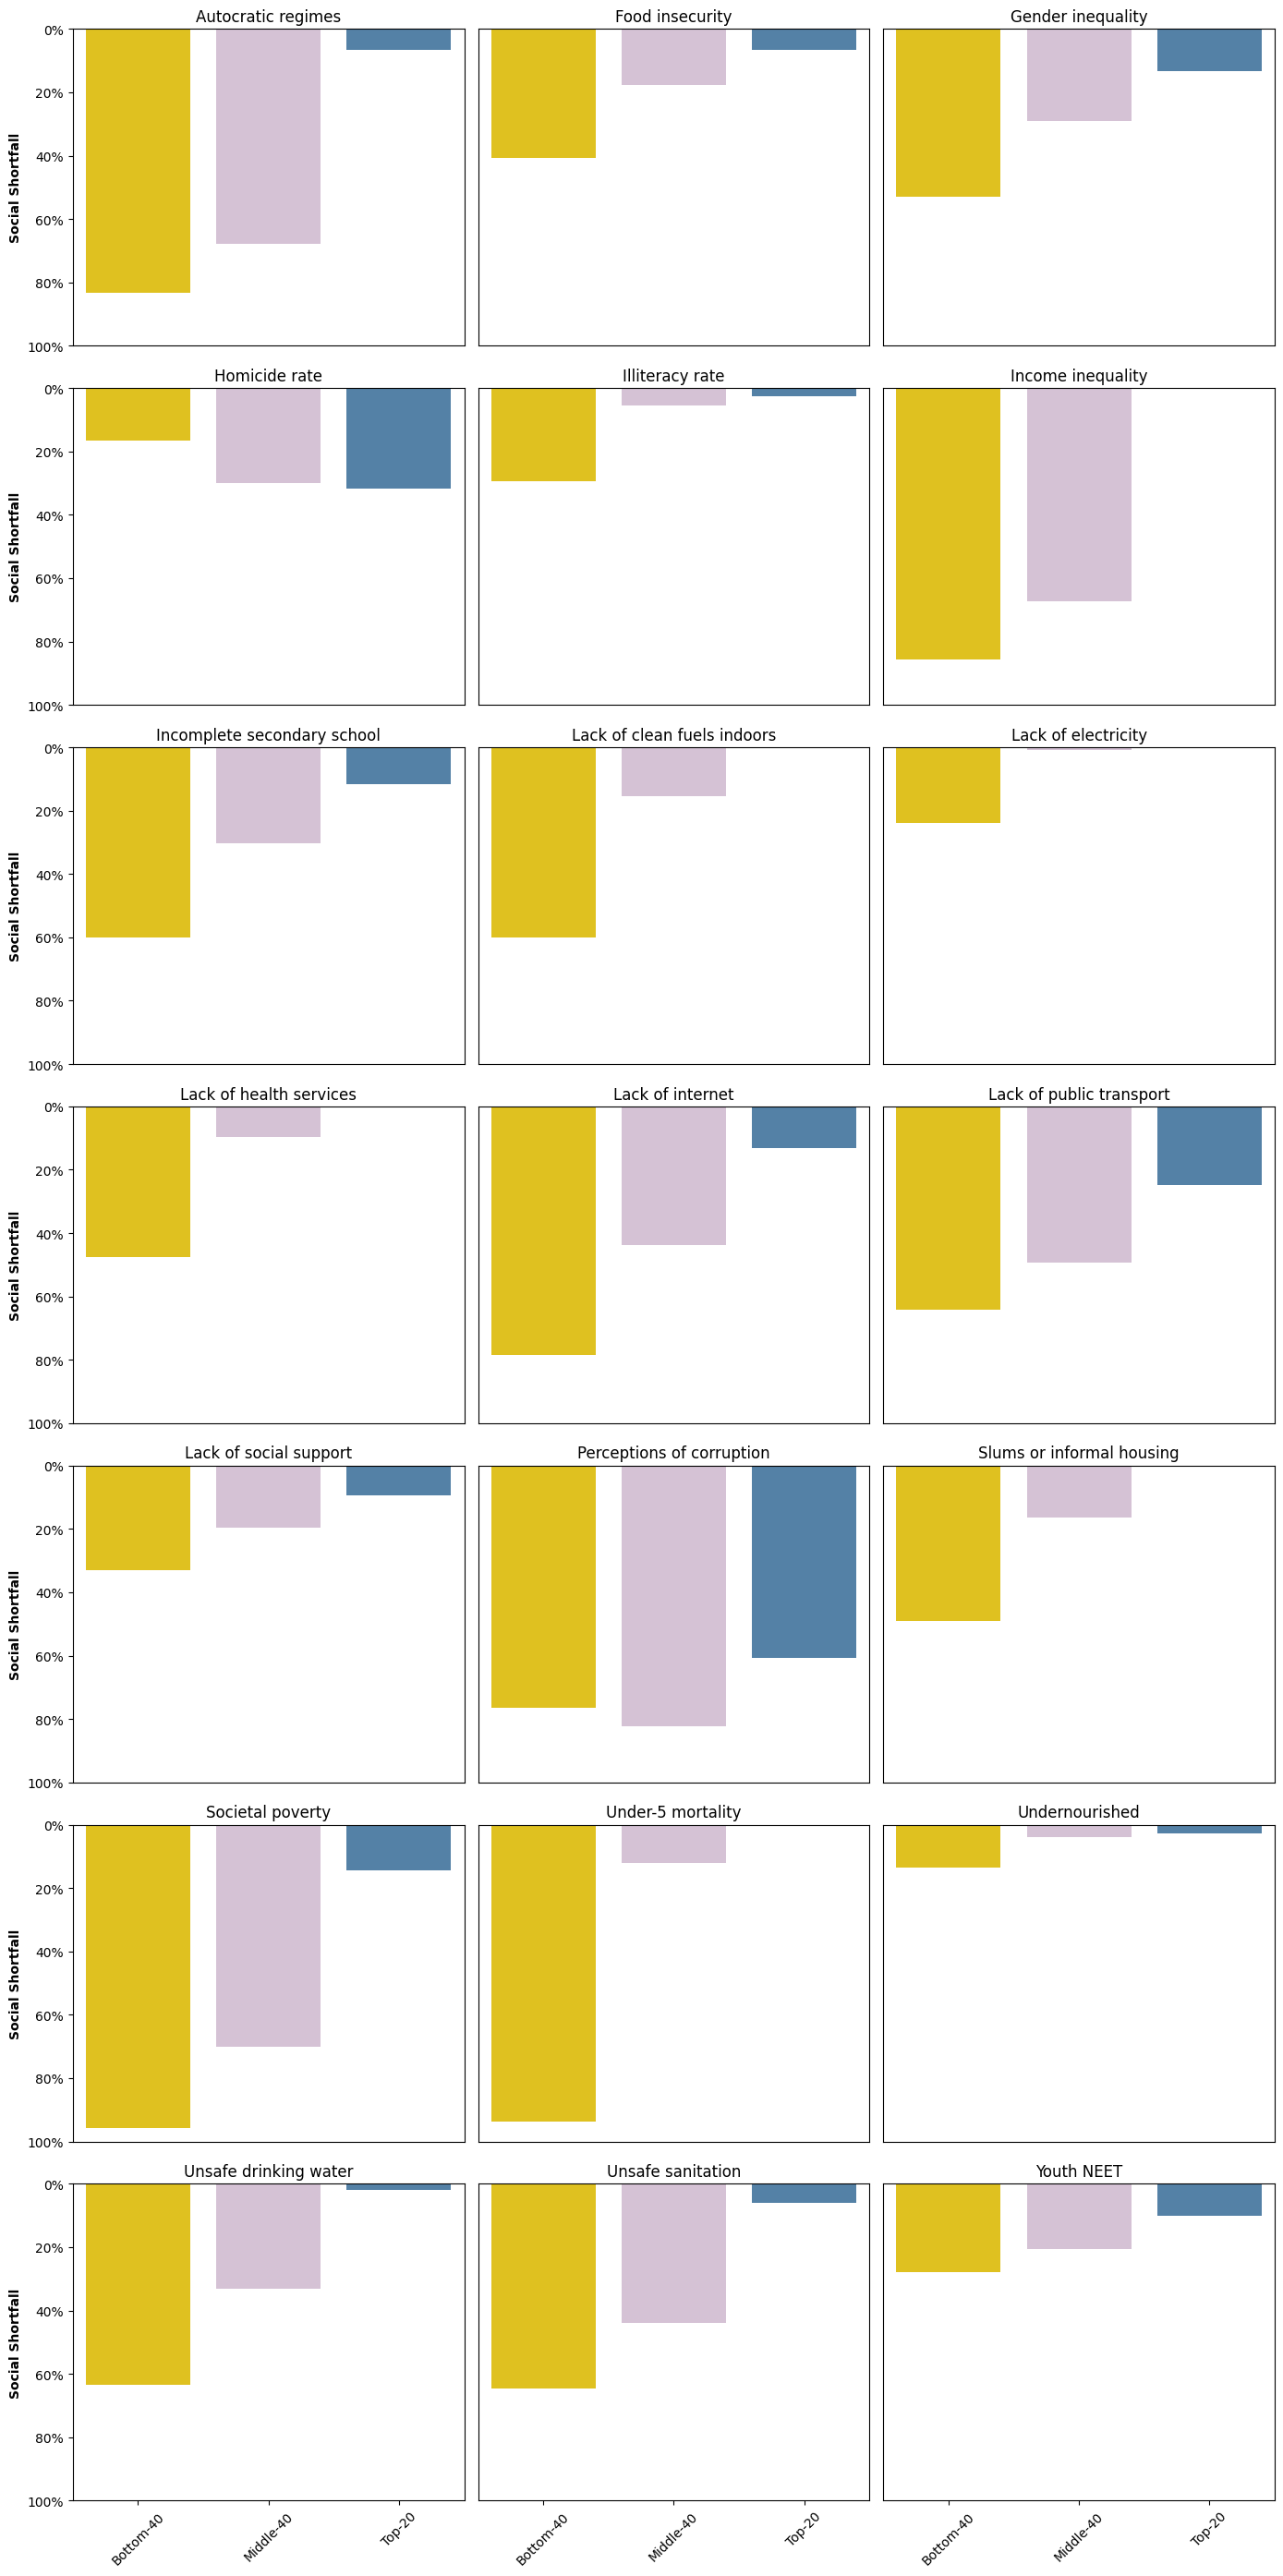

In [70]:
indicators = soc_chart['indicator'].unique()

n_cols = 3
n_rows = -(-len(indicators) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 4))
axes = axes.flatten()
palette = ['#ffd700', '#d8bfd8', '#4682b4']

for i, indicator in enumerate(indicators):
    ax = axes[i]
    data = soc_chart[soc_chart['indicator'] == indicator]
    
    if i % 3 != 0 :
        ax.yaxis.set_visible(False)
    else :
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())
        ax.set_ylabel('Social Shortfall', fontweight='bold')
    
    sns.barplot(data=data, x='group', y='value', hue='group', palette=palette, legend=False, ax=ax)
    ax.set_title(indicator)
    ax.set_ylim(0, 100)
    ax.invert_yaxis()
    ax.set(xlabel=None)
    ax.tick_params(axis='x', rotation=45)

for ax in axes[:-3]:
    ax.xaxis.set_visible(False)
    
    
plt.tight_layout()
plt.show()

In [112]:
eco_short = panel_data[panel_data['domain'] == 'ecological']

In [113]:
eco_short.reset_index(drop='True', inplace=True)

In [114]:
eco_short = eco_short.groupby(['indicator', 'group'])['value'].sum().reset_index()

In [115]:
footprint_map = {
    'N_footprint': 'Nitrogen footprint',
    'P_footprint': 'Phosphorus footprint',
    'blueH2O_footprint': 'Blue water footprint',
    'co2_footprint': 'Carbon footprint',
    'hanpp_footprint': 'HANPP footprint',
    'species_footprint': 'Species-loss footprint'
}

In [116]:
eco_short['indicator'] = eco_short['indicator'].map(footprint_map)

In [117]:
eco_short.sort_values(['indicator', 'group'], inplace=True)

In [118]:
#Correct data scale
eco_short.loc[eco_short['indicator'] == 'Carbon footprint', 'value'] = eco_short.loc[eco_short['indicator'] == 'Carbon footprint', 'value'] * 100
eco_short.loc[eco_short['indicator'] == 'Nitrogen footprint	', 'value'] = eco_short.loc[eco_short['indicator'] == 'Nitrogen footprint', 'value'] * 100
eco_short.loc[eco_short['indicator'] == 'Phosphorus footprint', 'value'] = eco_short.loc[eco_short['indicator'] == 'Phosphorus footprint', 'value'] * 100

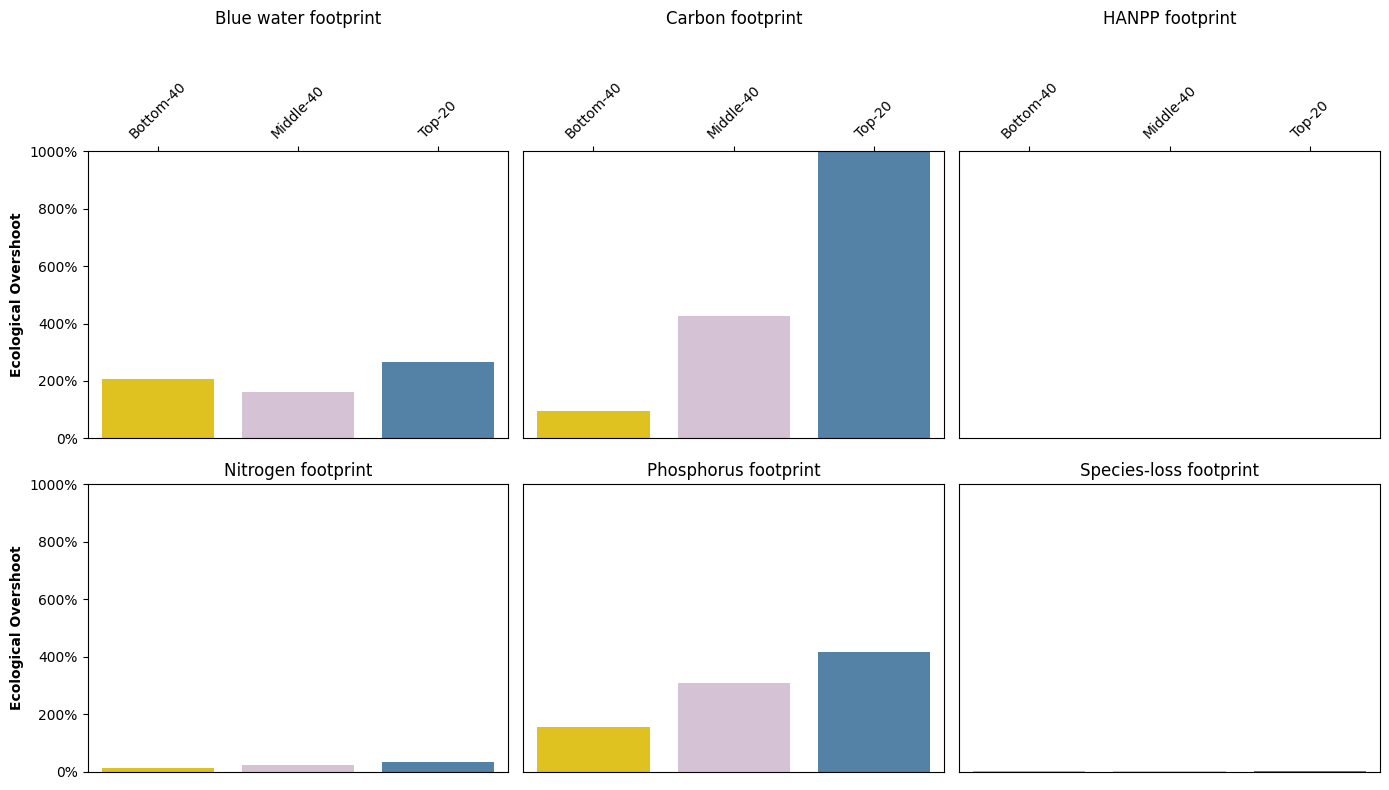

In [125]:
indicators2 = eco_short['indicator'].unique()

n_cols = 3
n_rows = -(-len(indicators2) // n_cols)

fig2, axes2 = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 4))
axes2 = axes2.flatten()

for i, indicator in enumerate(indicators2):
    ax = axes2[i]
    data2 = eco_short[eco_short['indicator'] == indicator]
    if i % 3 != 0:
        ax.yaxis.set_visible(False)
    else:
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())
        ax.set_ylabel('Ecological Overshoot', fontweight='bold')

    sns.barplot(data=data2, x='group', y='value', hue='group', palette=palette, legend=False, ax=ax)
    ax.set_ylim(0, 1000)
    ax.set(xlabel=None)

    if i < n_cols:
        ax.xaxis.set_ticks_position('top')
        ax.xaxis.set_label_position('top')
        ax.tick_params(axis='x', rotation=45)
        ax.set_title(indicator, pad=40)
    else:
        ax.set_title(indicator)

for ax in axes2[3:]:
    ax.xaxis.set_visible(False)

plt.tight_layout()
plt.show()

In [102]:
eco_short.reset_index(drop='True', inplace=True)
eco_short

,indicator,group,value
0,Blue water footprint,Bottom-40,207.119042
1,Blue water footprint,Middle-40,163.025563
2,Blue water footprint,Top-20,267.106573
3,Carbon footprint,Bottom-40,93.890363
4,Carbon footprint,Middle-40,425.670415
5,Carbon footprint,Top-20,1165.050884
6,HANPP footprint,Bottom-40,1.514648
7,HANPP footprint,Middle-40,2.042388
8,HANPP footprint,Top-20,3.058512
9,Nitrogen footprint,Bottom-40,10.597806
